In [ ]:
#  Objective:-The objective of this roduct is to develop a machine learnign based classification model that predicts the
#  geopolitical states between two contries using multidimensional features.The model to classify the relationalship into multiple
#  categories piece strategic compition cold war,proxy war,direct war,undirectwar based on factors such as mulitry strength,nuclear
#  capability, economic condition,idological ,polotical stability,historical context and sentiment analysis derived from media and
#  public score.Build and evaluate a neural network model using proper data set, validation and testing technique optimize model
#  performance through hyper parameter tuning and validation strategy.

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from tensorflow.keras.optimizers import Adam

In [ ]:
df=pd.read_csv("geopolitical_dataset.csv");

In [ ]:
print (df.head());

   military_power_ratio  troop_movement  nuclear_capability  nuclear_warheads  \
0              1.061810              46                   0                20   
1              1.926071              11                   0               157   
2              1.597991              61                   0               268   
3              1.397988              79                   0               161   
4              0.734028              87                   1               259   

   gdp_ratio  sanctions_intensity  trade_dependency  ideology_distance  \
0   1.514162                    7          0.949273           0.844864   
1   1.915973                    7          0.879601           0.359676   
2   0.903452                    9          0.907042           0.687234   
3   1.213110                    6          0.991533           0.312834   
4   1.451510                    4          0.208315           0.060906   

   political_stability  historical_conflict  border_distance  news_s

In [ ]:
print(df.info());

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   military_power_ratio  1000 non-null   float64
 1   troop_movement        1000 non-null   int64  
 2   nuclear_capability    1000 non-null   int64  
 3   nuclear_warheads      1000 non-null   int64  
 4   gdp_ratio             1000 non-null   float64
 5   sanctions_intensity   1000 non-null   int64  
 6   trade_dependency      1000 non-null   float64
 7   ideology_distance     1000 non-null   float64
 8   political_stability   1000 non-null   float64
 9   historical_conflict   1000 non-null   int64  
 10  border_distance       1000 non-null   float64
 11  news_sentiment        1000 non-null   float64
 12  nationalism_index     1000 non-null   float64
 13  leader_aggression     1000 non-null   float64
 14  target                1000 non-null   int64  
dtypes: float64(9), int64(6

In [ ]:
X=df.drop('target',axis=1)
Y=df['target']


In [ ]:
# First split: 70% train, 30% temp
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

# Second split: split 30% into 15% validation + 15% test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [ ]:
# MODEL 1

In [ ]:
import time
start_time = time.time()

In [ ]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(14,)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(6, activation='softmax'))


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, Y_val)
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4143 - loss: 1.4233 - val_accuracy: 0.5933 - val_loss: 1.1287
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5471 - loss: 1.0991 - val_accuracy: 0.7000 - val_loss: 0.8869
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6171 - loss: 0.9699 - val_accuracy: 0.7267 - val_loss: 0.7123
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6786 - loss: 0.8215 - val_accuracy: 0.7200 - val_loss: 0.6050
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7186 - loss: 0.7163 - val_accuracy: 0.7933 - val_loss: 0.5227
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7586 - loss: 0.5913 - val_accuracy: 0.8267 - val_loss: 0.4752
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7329 - loss: 0.6161 - val_accuracy: 0.8133 - val_loss: 0.4419
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7900 - loss: 0.5472 - val_accuracy: 0.8333 - val_loss:

In [ ]:
end_time = time.time()
time_softmax = end_time - start_time

print("Time (Softmax Model):", time_softmax, "seconds")

Time (Softmax Model): 14.905012607574463 seconds


In [ ]:
from tensorflow.keras.layers import Dense, Dropout, Input

In [ ]:
# MODEL 2

In [ ]:
start_time = time.time()

model2 = Sequential([
    Input(shape=(14,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(6)
])

model2.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, Y_val),
    verbose=0
)

end_time = time.time()
time_logits = end_time - start_time

print("Time (Logits Model):", time_logits, "seconds")

Time (Logits Model): 12.759339094161987 seconds


In [ ]:
loss, accuracy = model.evaluate(X_test, Y_test)
print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9200 - loss: 0.1504 

Test Loss: 0.15042990446090698
Test Accuracy: 0.9200000166893005


In [ ]:
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)

Y_true =  Y_test

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [ ]:
print(Y_pred_classes)

[2 3 1 1 3 2 2 2 2 1 1 2 2 2 1 2 3 1 1 0 2 2 1 2 2 2 3 2 2 1 2 1 3 3 2 1 1
 1 2 1 1 1 2 1 2 2 2 2 1 2 1 1 1 2 1 1 2 2 1 2 3 2 1 2 2 2 1 2 2 1 1 2 2 3
 2 1 1 1 1 1 2 1 2 0 0 3 3 2 1 2 2 3 2 1 1 3 1 0 3 1 1 1 3 1 3 1 2 1 1 1 1
 1 2 1 1 1 3 1 1 1 3 2 0 1 1 3 1 2 3 2 1 1 1 2 1 1 1 1 2 2 1 3 1 2 1 1 1 2
 2 2]


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(Y_true, Y_pred_classes))

print("\nClassification Report:")
print(classification_report(Y_true, Y_pred_classes))



Confusion Matrix:
[[ 2  0  0  0]
 [ 3 67  3  0]
 [ 0  2 51  2]
 [ 0  0  2 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      1.00      0.57         2
           1       0.97      0.92      0.94        73
           2       0.91      0.93      0.92        55
           3       0.90      0.90      0.90        20

    accuracy                           0.92       150
   macro avg       0.80      0.94      0.83       150
weighted avg       0.93      0.92      0.92       150



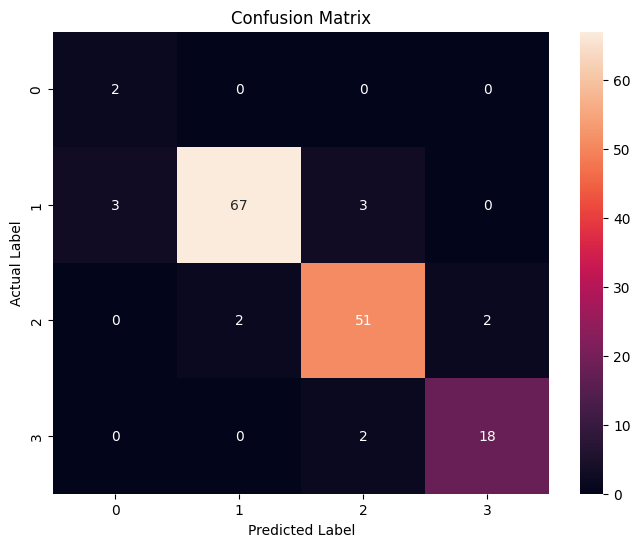

In [ ]:
cm = confusion_matrix(Y_true, Y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

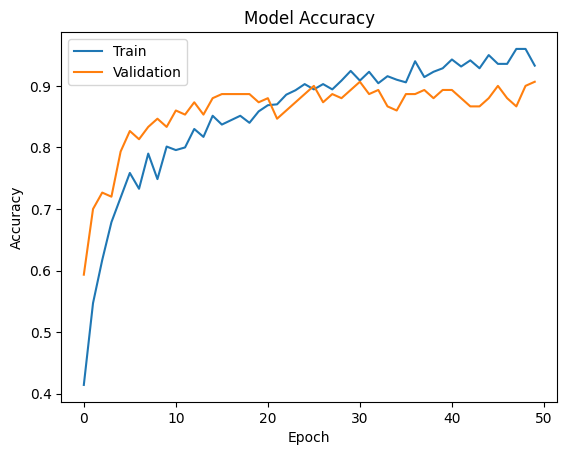

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


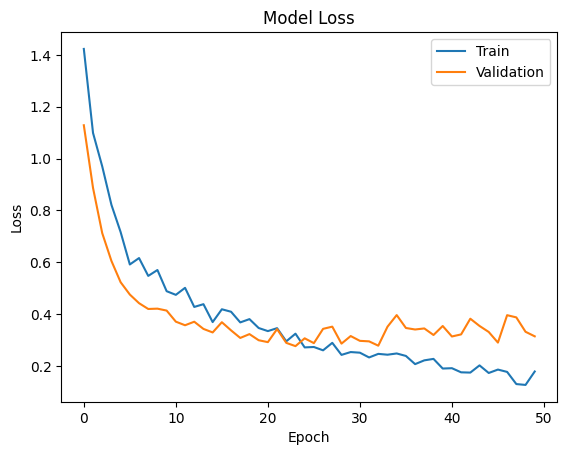

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


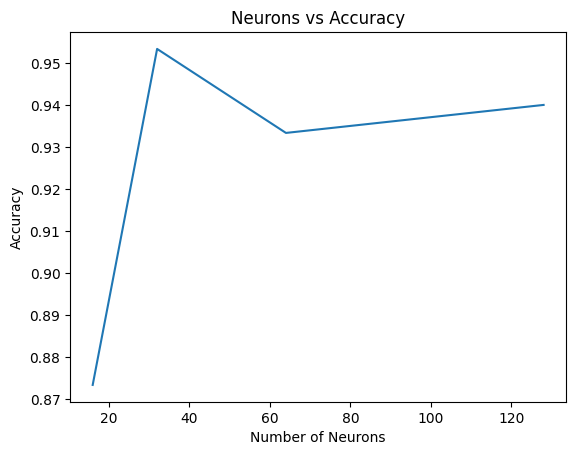

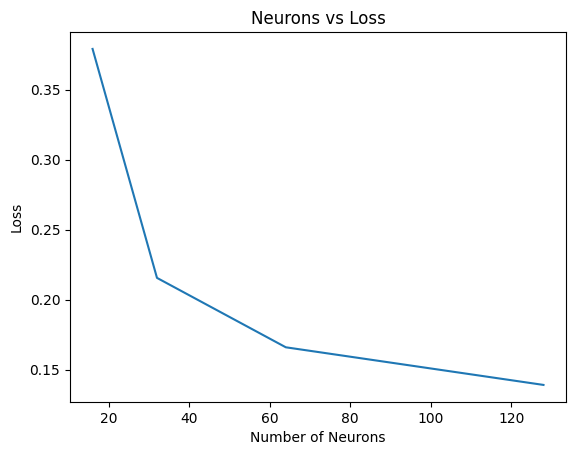

In [ ]:
neurons_list = [16, 32, 64, 128]
acc_list = []
loss_list = []

for n in neurons_list:
    model = Sequential([
        Dense(n, activation='relu', input_shape=(14,)),
        Dense(n//2, activation='relu'),
        Dense(6, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train, Y_train, epochs=20, batch_size=16, verbose=0)

    loss, acc = model.evaluate(X_test, Y_test, verbose=0)

    acc_list.append(acc)
    loss_list.append(loss)

# Plot Accuracy
plt.plot(neurons_list, acc_list)
plt.xlabel("Number of Neurons")
plt.ylabel("Accuracy")
plt.title("Neurons vs Accuracy")
plt.show()

# Plot Loss
plt.plot(neurons_list, loss_list)
plt.xlabel("Number of Neurons")
plt.ylabel("Loss")
plt.title("Neurons vs Loss")
plt.show()

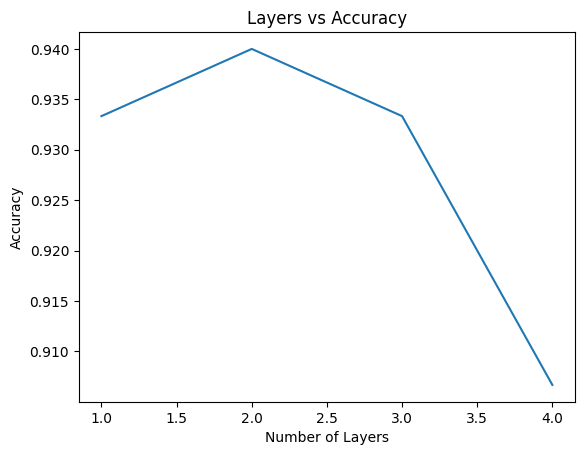

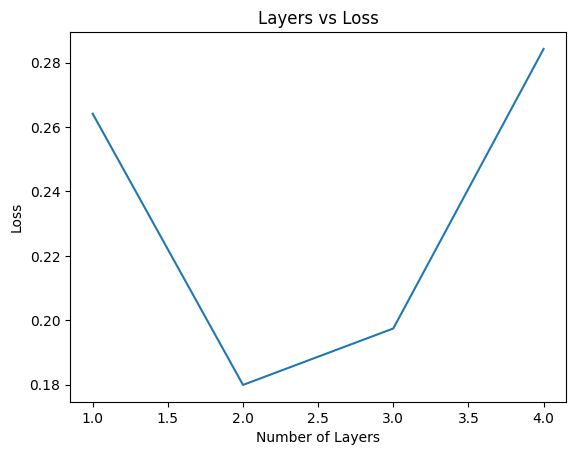

In [ ]:
layers_list = [1, 2, 3, 4]
acc_list = []
loss_list = []

for l in layers_list:
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(14,)))

    for i in range(l-1):
        model.add(Dense(64, activation='relu'))

    model.add(Dense(6, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(X_train, Y_train, epochs=20, batch_size=16, verbose=0)

    loss, acc = model.evaluate(X_test, Y_test, verbose=0)

    acc_list.append(acc)
    loss_list.append(loss)

# Accuracy
plt.plot(layers_list, acc_list)
plt.xlabel("Number of Layers")
plt.ylabel("Accuracy")
plt.title("Layers vs Accuracy")
plt.show()

# Loss
plt.plot(layers_list, loss_list)
plt.xlabel("Number of Layers")
plt.ylabel("Loss")
plt.title("Layers vs Loss")
plt.show()